# Estudo integrado - sistema multimodal de apoio à triagem de câncer de mama

Este notebook reúne os dois eixos do projeto - **dados estruturados** e **imagens de mamografia** - de uma forma metodologicamente consistente.

Há um ponto importante aqui: trabalhamos com duas bases diferentes, de **pacientes diferentes**. De um lado, temos exames tabulares do Breast Cancer Wisconsin; do outro, imagens do CBIS-DDSM. Como não existe correspondência entre paciente e imagem nas duas bases, **não seria correto fundir esses dados como se fossem da mesma pessoa**.

Por isso, a abordagem adotada neste estudo é a de um **sistema com roteamento por modalidade**. Em vez de misturar fontes incompatíveis, criamos um ponto único de entrada que recebe **ou um exame** **ou uma imagem**, identifica o tipo da entrada e encaminha para o modelo especialista adequado, devolvendo uma resposta padronizada.

Esse desenho é mais honesto do ponto de vista analítico e se aproxima melhor da forma como sistemas reais de apoio à decisão costumam ser organizados.

Neste notebook, seguimos o seguinte fluxo:

- módulo estruturado (exames)
- módulo de imagem (mamografias)
- comparação entre modalidades
- roteador multimodal `diagnosticar()`
- conclusão e próximos passos


## Preparação do ambiente

Nesta etapa, carregamos as bibliotecas necessárias e adicionamos o diretório `src/` ao caminho do Python para permitir a importação direta do pacote do projeto.

A parte de imagem depende do `torch`. Se ele não estiver disponível no ambiente, o notebook continua funcionando para o módulo estruturado e apenas pula a parte da CNN.


In [ ]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

from techchallenge import config
from techchallenge.data import estruturado as dados
from techchallenge.models import estruturado as modelos_estr
from techchallenge.evaluation import metrics

# O torch é opcional: o módulo de imagem só roda se estiver disponível.
try:
    import torch
    from torchvision import transforms
    from PIL import Image
    from techchallenge.models import cnn as cnn_mod
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print("Aviso: o torch não está disponível neste ambiente; a parte de imagem será ignorada.", e)

print("Torch disponível:", TORCH_OK)


torch disponivel: True


## A. Módulo estruturado (exames)

Aqui utilizamos o **Stacking**, que é o melhor modelo do módulo tabular. Ele combina os modelos de base do projeto e gera a predição final para os dados estruturados.


In [ ]:
df = dados.carregar_dados()
X_train, X_test, y_train, y_test = dados.preparar_treino_teste(df)

stack = modelos_estr.construir_stacking()
stack.fit(X_train, y_train)

prob_estrut = stack.predict_proba(X_test)[:, 1]
pred_estrut = (prob_estrut >= 0.5).astype(int)
m_estrut = metrics.metricas(y_test, pred_estrut)
print("Estruturado (Stacking):", {k: round(v, 4) for k, v in m_estrut.items()})
auc_estrut = roc_auc_score(y_test, prob_estrut)
print("AUC:", round(auc_estrut, 4))

Estruturado (Stacking): {'Accuracy': 0.9825, 'Recall (maligno)': 0.9524, 'F1 (maligno)': 0.9756}
AUC: 0.9954


## B. Módulo de imagem (mamografias)

Nesta parte, carregamos a CNN já treinada a partir dos arquivos salvos em `outputs/modelo_cnn_*.pt` e avaliamos seu desempenho no conjunto de teste do CBIS-DDSM.

Esse trecho depende de duas condições:

- `torch` instalado no ambiente
- existência de um modelo de imagem previamente treinado

Se uma dessas condições não for atendida, o notebook informa isso e segue sem quebrar a análise.


In [ ]:
prob_img = pred_img = y_img = None
m_img = auc_img = None

def _achar_modelo():
    import glob
    # Prioriza o modelo padrão; se ele não existir, usa o primeiro encontrado.
    preferido = config.OUTPUTS_DIR / f"modelo_cnn_{config.MODELO_CNN_PADRAO}.pt"
    if preferido.exists():
        return str(preferido)
    achados = glob.glob(str(config.OUTPUTS_DIR / "modelo_cnn_*.pt"))
    return achados[0] if achados else None

if TORCH_OK and _achar_modelo():
    caminho = _achar_modelo()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(caminho, map_location=device)
    tipo, img_size = ckpt["modelo"], ckpt["img_size"]
    modelo_img = cnn_mod.construir(tipo).to(device)
    modelo_img.load_state_dict(ckpt["state_dict"]); modelo_img.eval()

    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)), transforms.ToTensor(),
        transforms.Normalize(config.IMAGENET_MEAN, config.IMAGENET_STD)])

    man = pd.read_csv(config.MANIFESTO_CSV)
    man_test = man[man["split"] == "test"].reset_index(drop=True)
    probs, ys = [], []
    with torch.no_grad():
        for _, r in man_test.iterrows():
            cam = os.path.join(str(config.IMAGENS_RAIZ), r["caminho"])
            x = tfm(Image.open(cam).convert("RGB")).unsqueeze(0).to(device)
            probs.append(torch.sigmoid(modelo_img(x)).item()); ys.append(int(r["label"]))
    prob_img = np.array(probs); y_img = np.array(ys)
    pred_img = (prob_img >= 0.5).astype(int)
    m_img = metrics.metricas(y_img, pred_img)
    auc_img = roc_auc_score(y_img, prob_img)
    print(f"Imagem ({tipo}):", {k: round(v, 4) for k, v in m_img.items()}, "| AUC:", round(auc_img, 4))
else:
    print("Módulo de imagem ignorado: falta torch ou um modelo treinado.")
    print("Se quiser executar esta etapa, treine antes a CNN com: python -m techchallenge.cli.treinar_cnn --finetune")


Imagem (mobilenet): {'Accuracy': 0.6591, 'Recall (maligno)': 0.7101, 'F1 (maligno)': 0.6203} | AUC: 0.7392


## C. Estudo comparativo entre as modalidades

Depois de avaliar os dois módulos separadamente, comparamos as métricas e as curvas ROC lado a lado.

É importante reforçar que essa comparação **não representa fusão de dados**. Cada modelo é avaliado no seu próprio conjunto de teste, com bases diferentes. O objetivo aqui é entender o comportamento relativo de cada modalidade dentro do escopo do projeto.


In [ ]:
tabela = {"Estruturado (Stacking)": m_estrut}
if m_img: tabela["Imagem (CNN)"] = m_img
comp = pd.DataFrame(tabela).T.round(4)
if auc_img is not None: comp["AUC"] = [round(auc_estrut,4), round(auc_img,4)]
else: comp["AUC"] = [round(auc_estrut,4)]
comp

,Accuracy,Recall (maligno),F1 (maligno),AUC
Estruturado (Stacking),0.9825,0.9524,0.9756,0.9954
Imagem (CNN),0.6591,0.7101,0.6203,0.7392


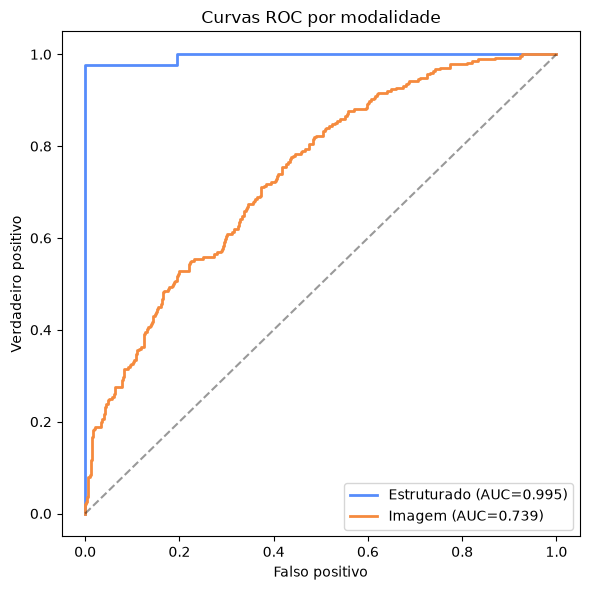

In [ ]:
plt.figure(figsize=(6,6))
fpr, tpr, _ = roc_curve(y_test, prob_estrut)
plt.plot(fpr, tpr, label=f"Estruturado (AUC={auc_estrut:.3f})", lw=2)
if prob_img is not None:
    fpr_i, tpr_i, _ = roc_curve(y_img, prob_img)
    plt.plot(fpr_i, tpr_i, label=f"Imagem (AUC={auc_img:.3f})", lw=2)
plt.plot([0,1],[0,1],"k--",alpha=0.4)
plt.xlabel("Falso positivo"); plt.ylabel("Verdadeiro positivo")
plt.title("Curvas ROC por modalidade"); plt.legend(); plt.tight_layout(); plt.show()

## D. Roteador multimodal - `diagnosticar()`

Nesta etapa, criamos um ponto de entrada único para o sistema. A função `diagnosticar()` recebe uma entrada, identifica se ela representa **um exame tabular** ou **uma imagem**, e então encaminha para o modelo correto.

A saída é padronizada, o que facilita o uso do sistema como uma camada de apoio à decisão.


In [ ]:
def _diag_exame(entrada):
    x = entrada.to_frame().T if isinstance(entrada, pd.Series) else pd.DataFrame(entrada)
    prob = float(stack.predict_proba(x)[:, 1][0])
    return {"modalidade": "exame tabular", "prob_maligno": prob,
            "diagnostico": "MALIGNO" if prob >= 0.5 else "BENIGNO"}

def _diag_imagem(caminho):
    if not (TORCH_OK and _achar_modelo()):
        return {"modalidade": "imagem", "erro": "modelo de imagem indisponível"}
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(_achar_modelo(), map_location=device)
    modelo = cnn_mod.construir(ckpt["modelo"]).to(device); modelo.load_state_dict(ckpt["state_dict"]); modelo.eval()
    tfm = transforms.Compose([transforms.Resize((ckpt["img_size"], ckpt["img_size"])) ,
        transforms.ToTensor(), transforms.Normalize(config.IMAGENET_MEAN, config.IMAGENET_STD)])
    x = tfm(Image.open(caminho).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = float(torch.sigmoid(modelo(x)).item())
    return {"modalidade": "imagem (mamografia)", "prob_maligno": prob,
            "diagnostico": "MALIGNO" if prob >= 0.5 else "BENIGNO"}

def diagnosticar(entrada):
    """Roteia exames tabulares para o Stacking e imagens (.jpg/.png) para a CNN."""
    if isinstance(entrada, str) and entrada.lower().endswith((".jpg", ".jpeg", ".png")):
        return _diag_imagem(entrada)
    return _diag_exame(entrada)

print("Roteador multimodal pronto.")


Roteador pronto.


### Demonstração com exame tabular

A seguir, simulamos a entrada de um exame no roteador para verificar como o sistema responde quando recebe dados estruturados.


In [ ]:
exemplo_exame = X_test.iloc[0]
print("Entrada: linha de exame com", len(exemplo_exame), "atributos")
print("Resultado:", diagnosticar(exemplo_exame))
print("Classe real:", "MALIGNO" if y_test.iloc[0]==1 else "BENIGNO")


Entrada: linha de exame com 30 features
Resultado: {'modalidade': 'exame (tabular)', 'prob_maligno': 0.014782037660671989, 'diagnostico': 'BENIGNO'}
Verdadeiro: BENIGNO


### Demonstração com imagem

Nesta etapa, fazemos a mesma demonstração, mas agora com uma imagem de mamografia - desde que o modelo de imagem esteja disponível no ambiente.


In [ ]:
if TORCH_OK and _achar_modelo():
    man = pd.read_csv(config.MANIFESTO_CSV)
    ex_img = os.path.join(str(config.IMAGENS_RAIZ), man[man.split=="test"].iloc[0]["caminho"])
    print("Entrada:", ex_img)
    print("Resultado:", diagnosticar(ex_img))
else:
    print("A demonstração com imagem requer torch e um modelo treinado (idealmente no ambiente com GPU).")


Entrada: D:\Projetos\FIAP\Tech Challenge 1\projeto\jpeg/1.3.6.1.4.1.9590.100.1.2.30820586311062570442302321942433426184/2-272.jpg
Resultado: {'modalidade': 'imagem (mamografia)', 'prob_maligno': 0.9228625297546387, 'diagnostico': 'MALIGNO'}


## E. Conclusão e próximos passos

O principal resultado deste notebook é mostrar que o projeto pode operar como um **sistema multimodal por roteamento**, recebendo diferentes tipos de entrada e delegando a análise ao modelo especialista adequado.

Esse desenho evita uma fusão artificial entre bases não pareadas e mantém a coerência metodológica do trabalho.

Em resumo:

- o **módulo estruturado** entrega desempenho forte e boa auditabilidade
- o **módulo de imagem** amplia o escopo do projeto para mamografias, ainda que com maior dificuldade de modelagem
- o **roteamento por modalidade** permite integrar as duas frentes em um único fluxo de uso

Como evolução futura, o caminho mais sólido seria trabalhar com um dataset que traga **as duas modalidades da mesma paciente**. Nesse cenário, aí sim faria sentido treinar uma fusão multimodal real, combinando evidências tabulares e visuais no mesmo modelo.

Em todos os casos, o sistema deve ser entendido como ferramenta de **apoio à decisão**, e não como substituto da avaliação médica.
